# Camera Trajectory Explorer
Explore output from `scripts/camera_trajectory.py`.
Visualizes 6-DOF camera pose, trajectory segmentation, and match quality.

In [78]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

# --- Configure which video to explore ---
VIDEO_PREFIX = "../local/videos/DJI_20250803143318_0215_D"

json_path = VIDEO_PREFIX + ".trajectory.json"
npz_path  = VIDEO_PREFIX + ".trajectory.npz"

with open(json_path) as f:
    traj = json.load(f)

data = np.load(npz_path)
poses_6dof    = data["poses_6dof"]     # (N, 6) [pan, tilt, roll, tx, ty, tz]
timestamps    = data["timestamps"]      # (N,)
inlier_ratios = data["inlier_ratios"]   # (N,)
n_matches     = data["n_matches"]       # (N,)

frames    = traj["frames"]
segments  = traj["segments"]
boundaries = traj["boundaries"]

df = pd.DataFrame(frames)
tx = np.array([f["translation_dir"][0] for f in frames])
ty = np.array([f["translation_dir"][1] for f in frames])
tz = np.array([f["translation_dir"][2] for f in frames])

print(f"Video:      {traj['video_path']}")
print(f"Backend:    {traj['backend']}")
print(f"Duration:   {traj['duration']:.1f}s")
print(f"Frames:     {traj['n_frames']}")
print(f"Segments:   {len(segments)}")
print(f"Boundaries: {[f'{b:.1f}s' for b in boundaries]}")

Video:      local/videos/DJI_20250803143318_0215_D.MP4
Backend:    superpoint_lightglue
Duration:   95.9s
Frames:     288
Segments:   14
Boundaries: ['35.0s', '46.7s', '53.3s', '56.7s', '58.3s', '63.3s', '66.7s', '71.7s', '76.7s', '81.7s', '86.7s', '91.7s', '95.0s']


## 3D Camera Translation Path
Translation direction is a unit vector — scale is not recovered in monocular VO.
The cumulative sum approximates the relative motion trajectory.

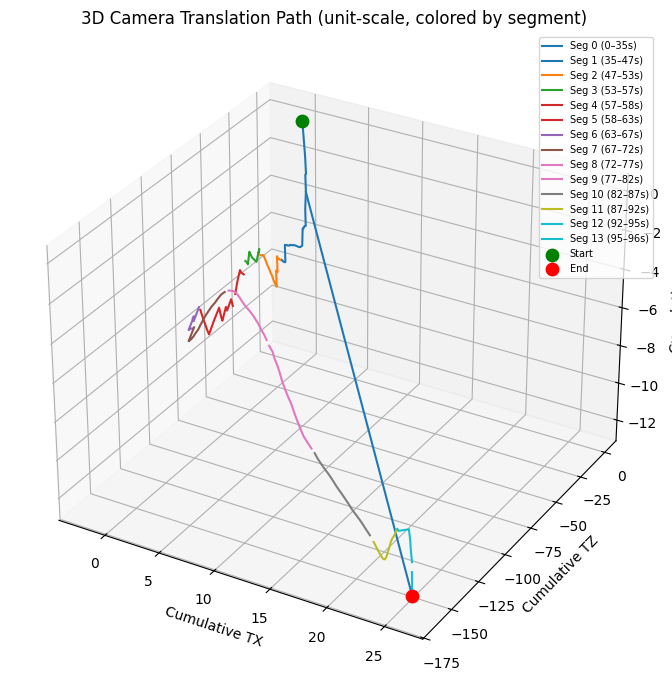

In [79]:
# Cumulative sum of translation unit vectors as proxy trajectory
cum_tx = np.cumsum(tx)
cum_ty = np.cumsum(ty)
cum_tz = np.cumsum(tz)

# Assign segment colors
seg_colors = cm.tab10(np.linspace(0, 1, max(len(segments), 1)))
frame_seg = np.zeros(len(frames), dtype=int)
for s in segments:
    mask = (df["timestamp"] >= s["start_time"]) & (df["timestamp"] < s["end_time"])
    frame_seg[mask.values] = s["segment_id"]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for seg_id in range(len(segments)):
    mask = frame_seg == seg_id
    ax.plot(
        cum_tx[mask], cum_tz[mask], cum_ty[mask],
        color=seg_colors[seg_id % len(seg_colors)],
        label=f"Seg {seg_id} ({segments[seg_id]['start_time']:.0f}–{segments[seg_id]['end_time']:.0f}s)",
        linewidth=1.5,
    )

ax.scatter([cum_tx[0]], [cum_tz[0]], [cum_ty[0]], c='green', s=80, zorder=5, label="Start")
ax.scatter([cum_tx[-1]], [cum_tz[-1]], [cum_ty[-1]], c='red', s=80, zorder=5, label="End")

ax.set_xlabel("Cumulative TX")
ax.set_ylabel("Cumulative TZ")
ax.set_zlabel("Cumulative TY")
ax.set_title("3D Camera Translation Path (unit-scale, colored by segment)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 6-DOF Components Over Time
Pan / tilt / roll in degrees, and translation unit vector components.

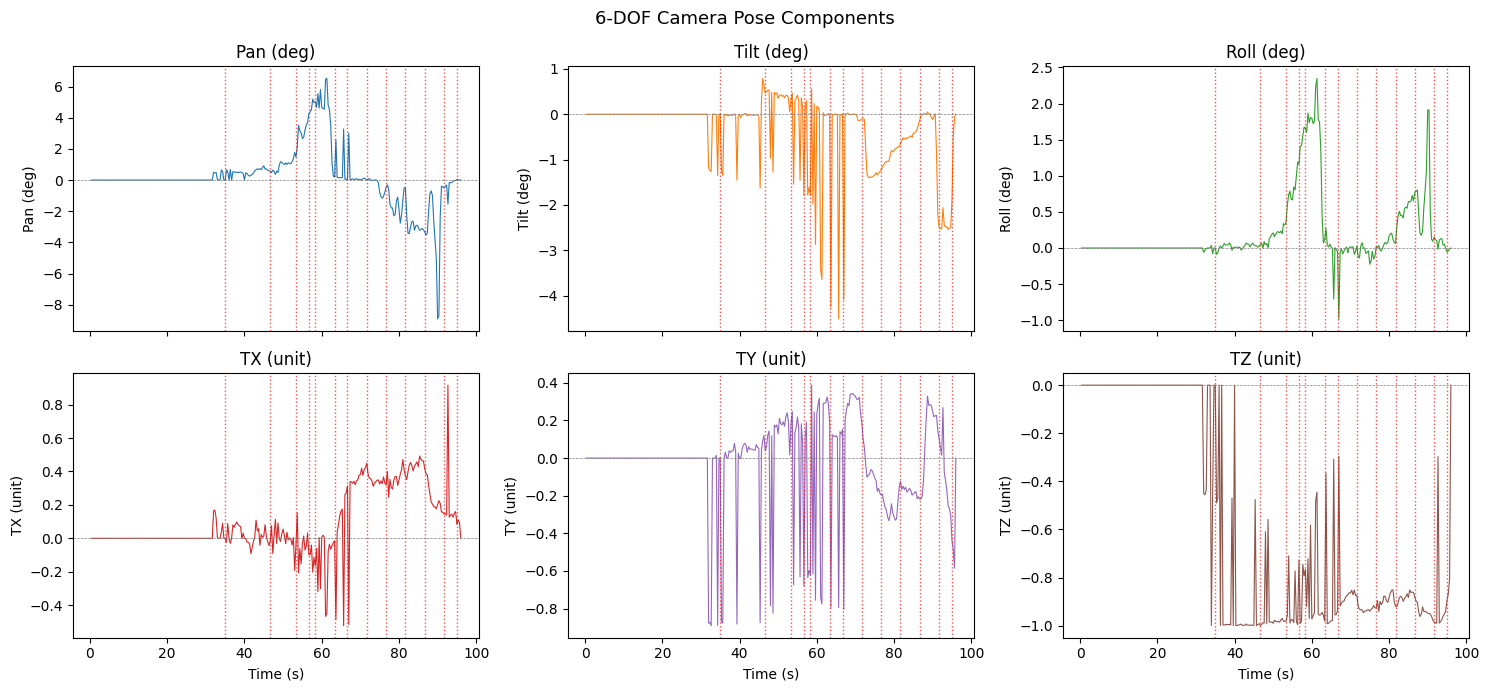

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
fig.suptitle("6-DOF Camera Pose Components", fontsize=13)

labels_top    = [("pan_deg", "Pan (deg)", "C0"),
                 ("tilt_deg", "Tilt (deg)", "C1"),
                 ("roll_deg", "Roll (deg)", "C2")]
labels_bottom = [(tx, "TX (unit)", "C3"),
                 (ty, "TY (unit)", "C4"),
                 (tz, "TZ (unit)", "C5")]

t = df["timestamp"].values

for ax, (col, ylabel, color) in zip(axes[0], labels_top):
    ax.plot(t, df[col].values, color=color, linewidth=0.8)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    for b in boundaries:
        ax.axvline(b, color="red", linewidth=1, linestyle=":", alpha=0.7)
    ax.set_title(ylabel)

for ax, (arr, ylabel, color) in zip(axes[1], labels_bottom):
    ax.plot(t, arr, color=color, linewidth=0.8)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time (s)")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    for b in boundaries:
        ax.axvline(b, color="red", linewidth=1, linestyle=":", alpha=0.7)
    ax.set_title(ylabel)

plt.tight_layout()
plt.show()

## Pose Velocity (Motion Speed Signal)
L2 norm of the 6-DOF vector — a single "how much is the camera moving" signal.

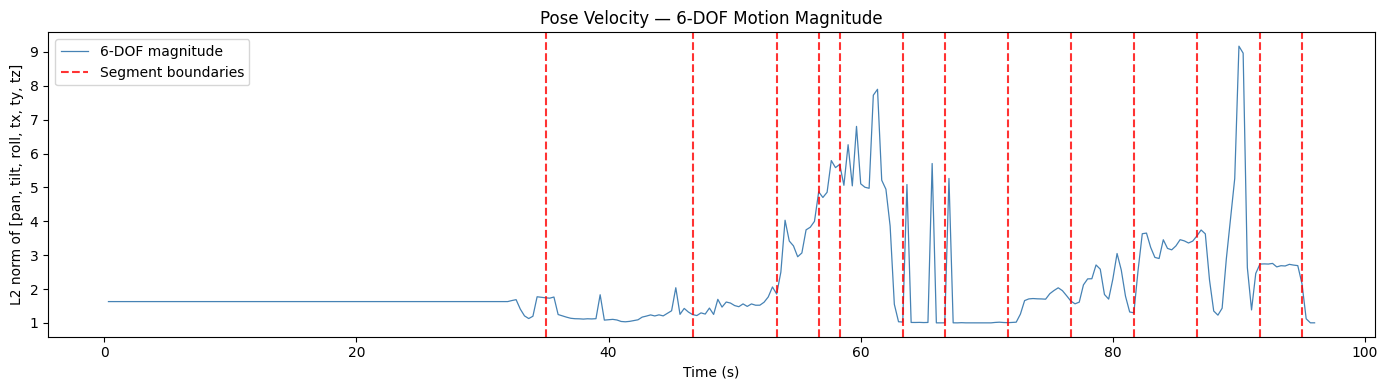

In [81]:
velocity = np.linalg.norm(poses_6dof, axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps, velocity, linewidth=0.9, color="steelblue", label="6-DOF magnitude")
for b in boundaries:
    ax.axvline(b, color="red", linewidth=1.5, linestyle="--", alpha=0.8, label="_")
ax.set_xlabel("Time (s)")
ax.set_ylabel("L2 norm of [pan, tilt, roll, tx, ty, tz]")
ax.set_title("Pose Velocity — 6-DOF Motion Magnitude")
ax.legend(["6-DOF magnitude", "Segment boundaries"])
plt.tight_layout()
plt.show()

## Segmentation Penalty Tuning
How does the number of segments change with the Pelt penalty?

penalty=3  model=l1  signals=['pan', 'tilt', 'tx', 'ty', 'tz']
medfilt  (12 boundaries):  ['35.0s', '46.7s', '56.7s', '58.3s', '63.3s', '66.7s', '71.7s', '76.7s', '81.7s', '86.7s', '91.7s', '95.0s']
savgol   (10 boundaries): ['33.3s', '36.7s', '53.3s', '56.7s', '61.7s', '68.3s', '71.7s', '78.3s', '86.7s', '91.7s']


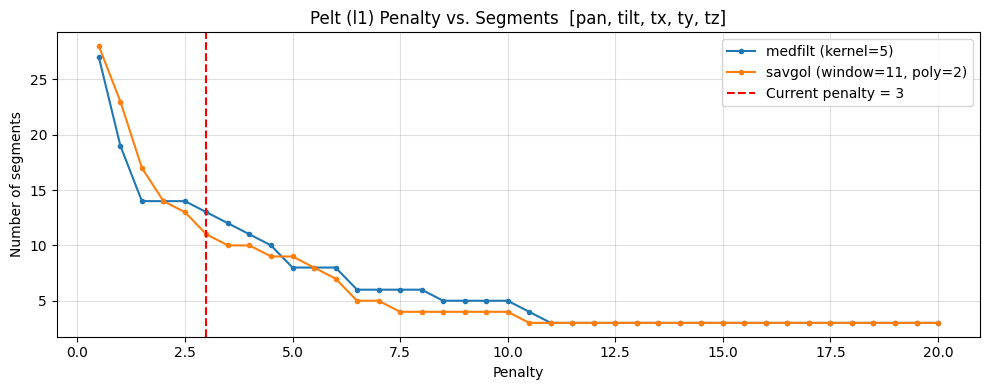

In [87]:
import ruptures as rpt
from scipy.signal import medfilt, savgol_filter

# --- Config ---
MEDFILT_KERNEL   = 5
SAVGOL_WINDOW    = 11   # must be odd and > polyorder
SAVGOL_POLYORDER = 2
PELT_MODEL       = "l1"

# Only pan and tilt drive the segmentation
# poses_6dof columns: [pan, tilt, roll, tx, ty, tz]
SIGNAL_COLS  = [0, 1, 3, 4, 5]
SIGNAL_NAMES = ["pan", "tilt", "tx", "ty","tz"]

def preprocess(poses, filter_fn, cols=SIGNAL_COLS):
    X = poses[:, cols].copy().astype(np.float64)
    for i in range(X.shape[1]):
        X[:, i] = filter_fn(X[:, i])
    for i in range(X.shape[1]):
        col_min, col_max = X[:, i].min(), X[:, i].max()
        if col_max - col_min > 1e-8:
            X[:, i] = (X[:, i] - col_min) / (col_max - col_min)
    return X

def boundaries_from(X, penalty):
    bps = rpt.Pelt(model=PELT_MODEL).fit(X).predict(pen=penalty)
    return [float(timestamps[b - 1]) for b in bps if b < len(timestamps)]

X_med    = preprocess(poses_6dof, lambda col: medfilt(col, kernel_size=MEDFILT_KERNEL))
X_savgol = preprocess(poses_6dof, lambda col: savgol_filter(col, window_length=SAVGOL_WINDOW,
                                                             polyorder=SAVGOL_POLYORDER))

pen = 3#traj["ruptures_penalty"]
boundaries_med    = boundaries_from(X_med,    pen)
boundaries_savgol = boundaries_from(X_savgol, pen)

print(f"penalty={pen}  model={PELT_MODEL}  signals={SIGNAL_NAMES}")
print(f"medfilt  ({len(boundaries_med)} boundaries):  {[f'{b:.1f}s' for b in boundaries_med]}")
print(f"savgol   ({len(boundaries_savgol)} boundaries): {[f'{b:.1f}s' for b in boundaries_savgol]}")

variants = [
    (f"medfilt (kernel={MEDFILT_KERNEL})",                        X,    "C0"),
    (f"savgol (window={SAVGOL_WINDOW}, poly={SAVGOL_POLYORDER})", X_savgol, "C1"),
]

penalties = np.linspace(0.5, 20.0, 40)

fig, ax = plt.subplots(figsize=(10, 4))
for label, X, color in variants:
    n_segs = [len(rpt.Pelt(model=PELT_MODEL).fit(X).predict(pen=p)) for p in penalties]
    ax.plot(penalties, n_segs, marker="o", markersize=3, linewidth=1.5, color=color, label=label)

ax.axvline(pen, color="red", linestyle="--", label=f"Current penalty = {pen}")
ax.set_xlabel("Penalty")
ax.set_ylabel("Number of segments")
ax.set_title(f"Pelt ({PELT_MODEL}) Penalty vs. Segments  [{', '.join(SIGNAL_NAMES)}]")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Keep X pointing at the pipeline default (medfilt) for downstream cells
X = X_med

IndexError: index 5 is out of bounds for axis 1 with size 5

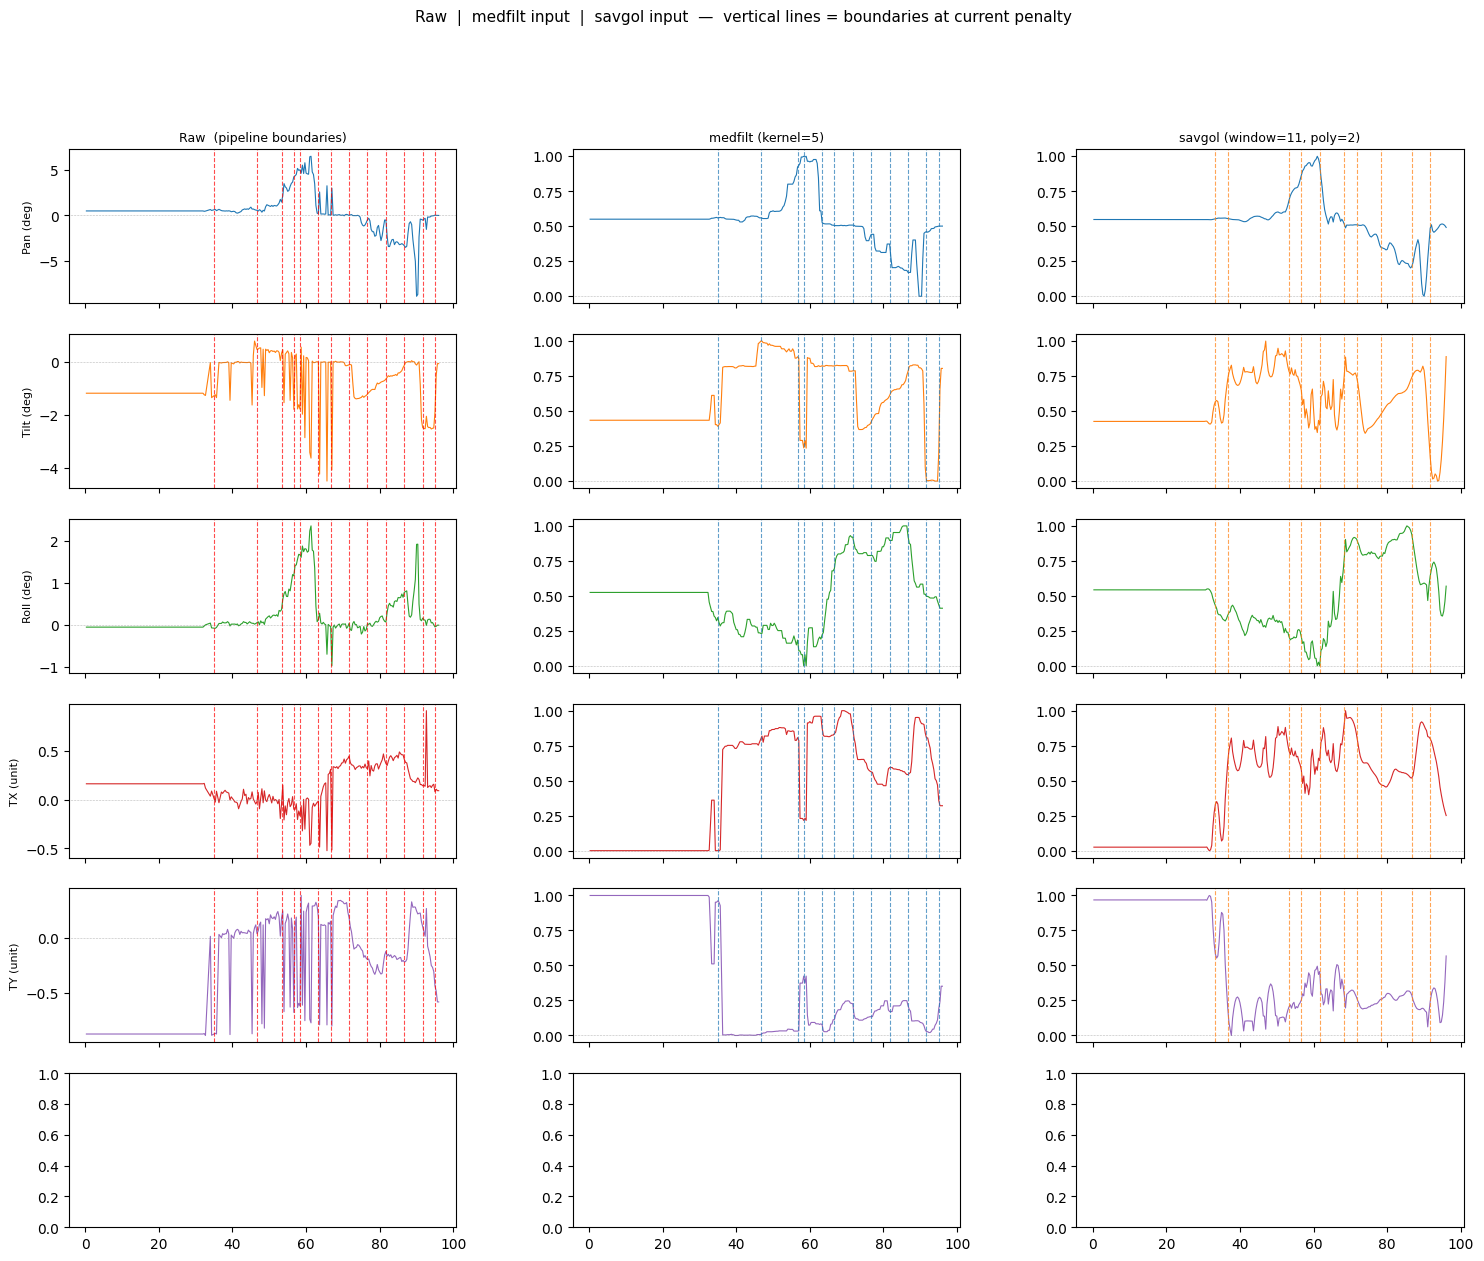

In [88]:
col_labels = ["Pan (deg)", "Tilt (deg)", "Roll (deg)", "TX (unit)", "TY (unit)", "TZ (unit)"]

col_titles = [
    "Raw  (pipeline boundaries)",
    f"medfilt (kernel={MEDFILT_KERNEL})",
    f"savgol (window={SAVGOL_WINDOW}, poly={SAVGOL_POLYORDER})",
]
# boundaries per column: raw column shows the original pipeline result
col_boundaries = [boundaries, boundaries_med, boundaries_savgol]
col_bcolors    = ["red", "C0", "C1"]

fig, axes = plt.subplots(6, 3, figsize=(18, 14), sharex=True,
                         gridspec_kw={"wspace": 0.3})
fig.suptitle("Raw  |  medfilt input  |  savgol input  —  vertical lines = boundaries at current penalty",
             fontsize=11)

for i, label in enumerate(col_labels):
    data_cols = [poses_6dof[:, i], X_med[:, i], X_savgol[:, i]]

    for j, (arr, title, bds, bcol) in enumerate(
            zip(data_cols, col_titles, col_boundaries, col_bcolors)):
        ax = axes[i, j]
        ax.plot(timestamps, arr, linewidth=0.8, color=f"C{i}")
        ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")
        if i == 0:
            ax.set_title(title, fontsize=9)
        if j == 0:
            ax.set_ylabel(label, fontsize=8)
        for b in bds:
            ax.axvline(b, color=bcol, linewidth=0.8, linestyle="--", alpha=0.7)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
axes[-1, 2].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Segmentation Preview for a Specific Penalty
Set `PREVIEW_PENALTY` and re-run to see how the trajectory would be segmented.

Penalty 3  →  15 segments
Boundaries: ['13.3s', '40.0s', '48.3s', '53.3s', '55.0s', '56.7s', '61.7s', '65.0s', '70.0s', '73.3s', '98.3s', '101.7s', '108.3s', '113.3s']


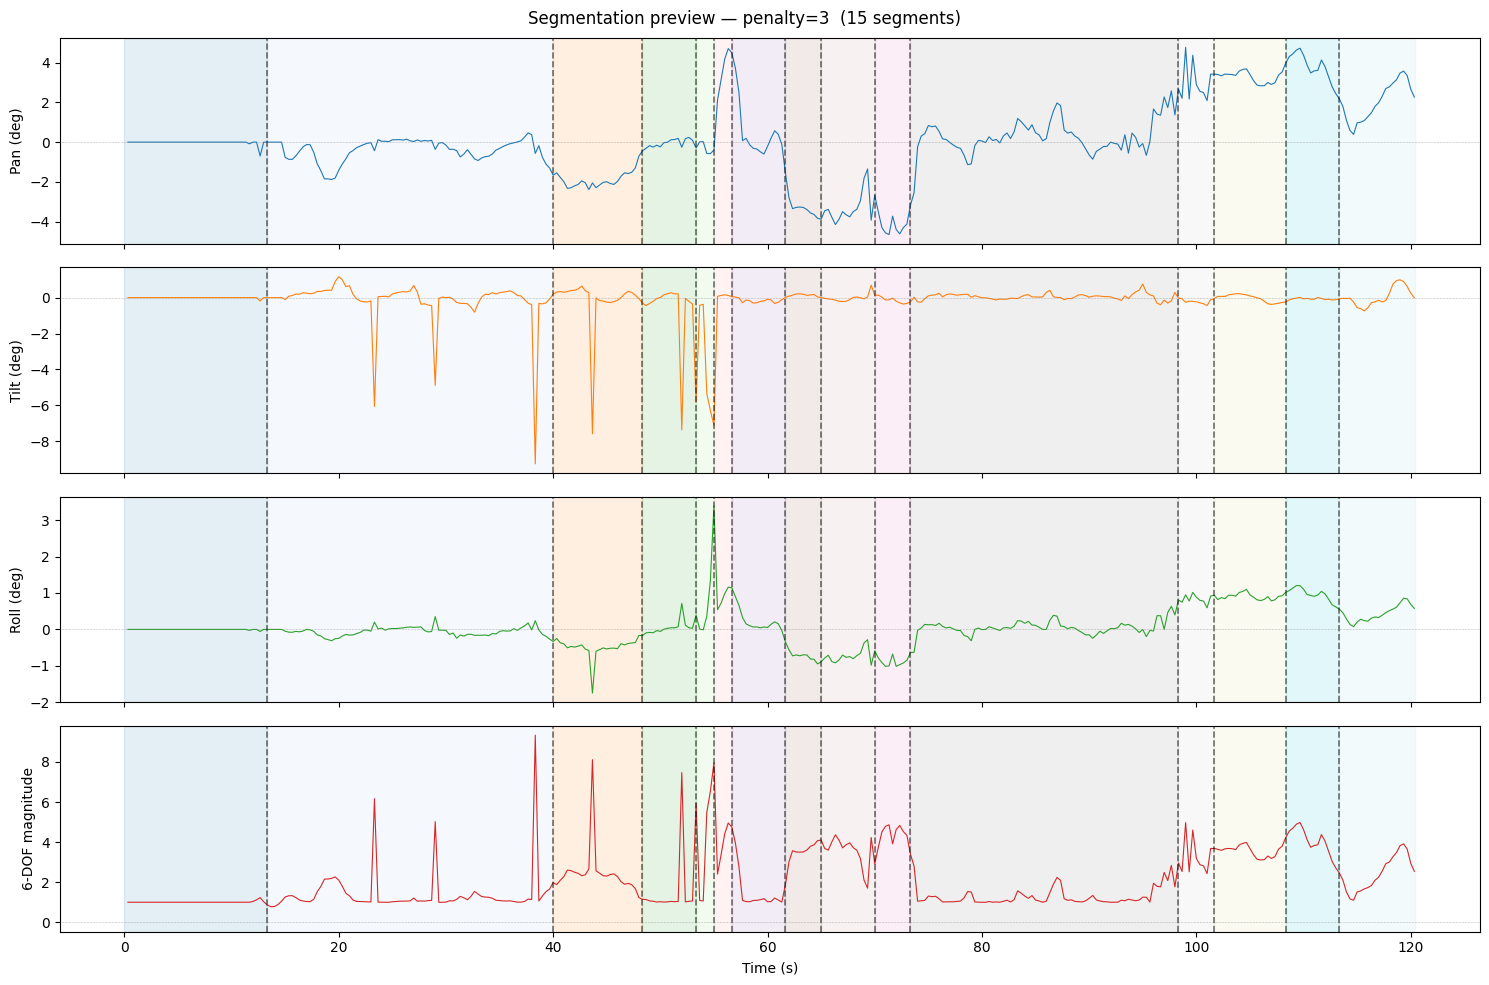

Penalty 3.5  →  13 segments
Boundaries: ['13.3s', '40.0s', '48.3s', '53.3s', '55.0s', '56.7s', '61.7s', '70.0s', '73.3s', '98.3s', '101.7s', '108.3s']


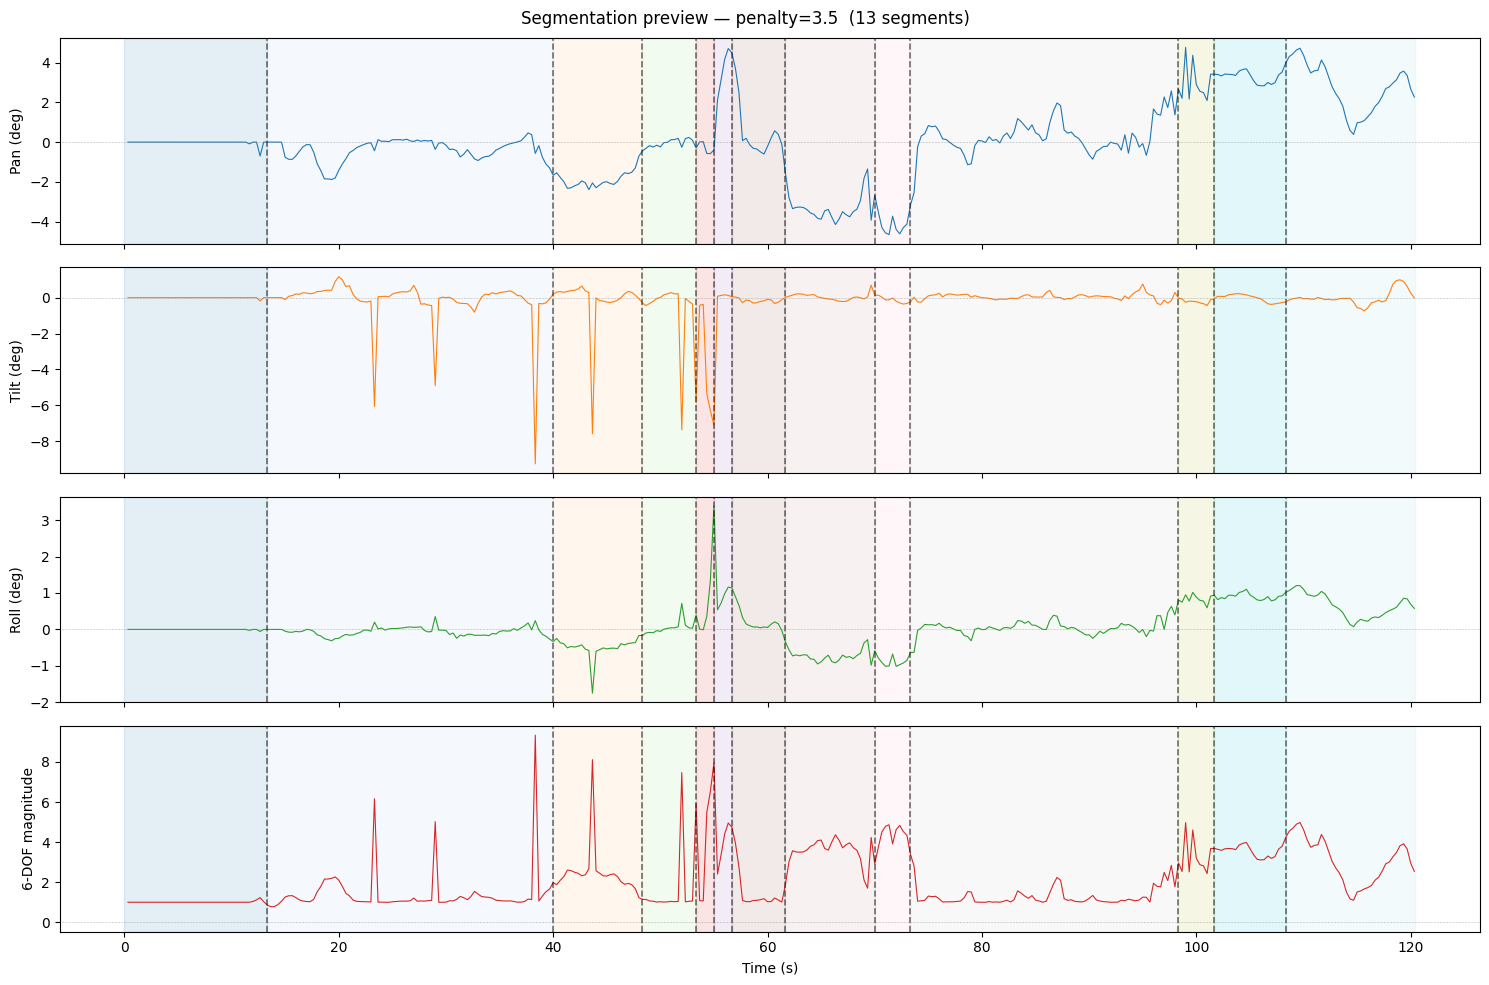

In [6]:
PREVIEW_PENALTY = 3

bps = model.predict(pen=PREVIEW_PENALTY)
bp_indices = [b - 1 for b in bps if b < len(timestamps)]
preview_boundaries = [float(timestamps[i]) for i in bp_indices]
n_preview_segs = len(bps)  # includes the final breakpoint

print(f"Penalty {PREVIEW_PENALTY}  →  {n_preview_segs} segments")
print(f"Boundaries: {[f'{b:.1f}s' for b in preview_boundaries]}")

# Assign per-frame segment index
seg_ids = np.searchsorted(preview_boundaries, timestamps)
colors_preview = cm.tab20(np.linspace(0, 1, max(n_preview_segs, 1)))

velocity = np.linalg.norm(poses_6dof, axis=1)
t = df["timestamp"].values

signals = [
    (df["pan_deg"].values,  "Pan (deg)",      "C0"),
    (df["tilt_deg"].values, "Tilt (deg)",     "C1"),
    (df["roll_deg"].values, "Roll (deg)",     "C2"),
    (velocity,              "6-DOF magnitude","C3"),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Segmentation preview — penalty={PREVIEW_PENALTY}  ({n_preview_segs} segments)", fontsize=12)

seg_starts = [0.0] + preview_boundaries
seg_ends   = preview_boundaries + [float(traj["duration"])]

for ax, (signal, ylabel, color) in zip(axes, signals):
    for i, (s, e) in enumerate(zip(seg_starts, seg_ends)):
        ax.axvspan(s, e, alpha=0.12, color=colors_preview[i % len(colors_preview)])
    ax.plot(t, signal, color=color, linewidth=0.8)
    for b in preview_boundaries:
        ax.axvline(b, color="black", linewidth=1.2, linestyle="--", alpha=0.55)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()



PREVIEW_PENALTY = 3.5

bps = model.predict(pen=PREVIEW_PENALTY)
bp_indices = [b - 1 for b in bps if b < len(timestamps)]
preview_boundaries = [float(timestamps[i]) for i in bp_indices]
n_preview_segs = len(bps)  # includes the final breakpoint

print(f"Penalty {PREVIEW_PENALTY}  →  {n_preview_segs} segments")
print(f"Boundaries: {[f'{b:.1f}s' for b in preview_boundaries]}")

# Assign per-frame segment index
seg_ids = np.searchsorted(preview_boundaries, timestamps)
colors_preview = cm.tab20(np.linspace(0, 1, max(n_preview_segs, 1)))

velocity = np.linalg.norm(poses_6dof, axis=1)
t = df["timestamp"].values

signals = [
    (df["pan_deg"].values,  "Pan (deg)",      "C0"),
    (df["tilt_deg"].values, "Tilt (deg)",     "C1"),
    (df["roll_deg"].values, "Roll (deg)",     "C2"),
    (velocity,              "6-DOF magnitude","C3"),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Segmentation preview — penalty={PREVIEW_PENALTY}  ({n_preview_segs} segments)", fontsize=12)

seg_starts = [0.0] + preview_boundaries
seg_ends   = preview_boundaries + [float(traj["duration"])]

for ax, (signal, ylabel, color) in zip(axes, signals):
    for i, (s, e) in enumerate(zip(seg_starts, seg_ends)):
        ax.axvspan(s, e, alpha=0.12, color=colors_preview[i % len(colors_preview)])
    ax.plot(t, signal, color=color, linewidth=0.8)
    for b in preview_boundaries:
        ax.axvline(b, color="black", linewidth=1.2, linestyle="--", alpha=0.55)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Match Quality
Number of SuperPoint + LightGlue matches and inlier ratio over time.
Low inlier ratio indicates difficult frames (motion blur, scene change, tracking lost).

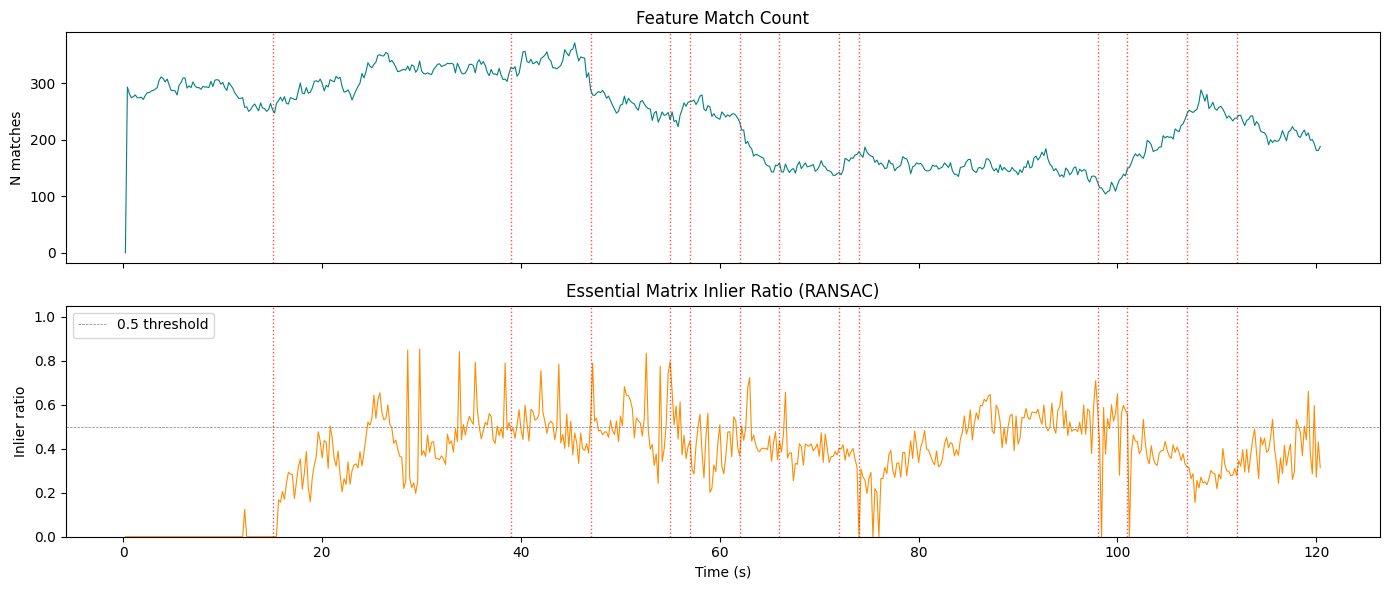

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(timestamps, n_matches, linewidth=0.8, color="teal")
ax1.set_ylabel("N matches")
ax1.set_title("Feature Match Count")
for b in boundaries:
    ax1.axvline(b, color="red", linewidth=1, linestyle=":", alpha=0.7)

ax2.plot(timestamps, inlier_ratios, linewidth=0.8, color="darkorange")
ax2.axhline(0.5, color="gray", linewidth=0.5, linestyle="--", label="0.5 threshold")
ax2.set_ylabel("Inlier ratio")
ax2.set_xlabel("Time (s)")
ax2.set_title("Essential Matrix Inlier Ratio (RANSAC)")
ax2.set_ylim(0, 1.05)
ax2.legend()
for b in boundaries:
    ax2.axvline(b, color="red", linewidth=1, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

## Segment Statistics
Summary table of mean camera motion per detected segment.

In [14]:
seg_df = pd.DataFrame(segments)
seg_df["duration"] = seg_df["end_time"] - seg_df["start_time"]

# Add mean inlier ratio per segment
def seg_mean_inlier(s):
    mask = (df["timestamp"] >= s["start_time"]) & (df["timestamp"] < s["end_time"])
    vals = df.loc[mask, "inlier_ratio"].values
    return float(np.mean(vals)) if len(vals) else 0.0

seg_df["mean_inlier_ratio"] = [seg_mean_inlier(s) for s in segments]

# Dominant rotation axis per segment
def dominant_axis(s):
    vals = {
        "pan":  abs(s["mean_pan_deg"]),
        "tilt": abs(s["mean_tilt_deg"]),
        "roll": abs(s["mean_roll_deg"]),
    }
    return max(vals, key=vals.get)

seg_df["dominant_axis"] = [dominant_axis(s) for s in segments]

display_cols = [
    "segment_id", "start_time", "end_time", "duration",
    "n_frames", "mean_pan_deg", "mean_tilt_deg", "mean_roll_deg",
    "mean_inlier_ratio", "dominant_axis",
]
pd.set_option("display.float_format", "{:.2f}".format)
seg_df[display_cols]

,segment_id,start_time,end_time,duration,n_frames,mean_pan_deg,mean_tilt_deg,mean_roll_deg,mean_inlier_ratio,dominant_axis
0,0,0.00,15.00,15.00,74,-0.00,-0.00,0.00,0.00,pan
1,1,15.00,39.00,24.00,120,-0.26,-0.12,-0.05,0.40,pan
2,2,39.00,47.00,8.00,40,-1.31,-0.12,-0.44,0.49,pan
3,3,47.00,55.00,8.00,40,-0.14,-0.37,0.01,0.52,tilt
4,4,55.00,57.00,2.00,10,1.89,-0.36,0.89,0.52,pan
5,5,57.00,62.00,5.00,25,-0.03,-0.11,0.10,0.40,tilt
6,6,62.00,66.00,4.00,20,-2.31,-0.42,-0.80,0.45,pan
7,7,66.00,72.00,6.00,30,-1.83,-0.24,-0.72,0.40,pan
8,8,72.00,74.00,2.00,10,-1.40,-0.24,-0.31,0.38,pan
9,9,74.00,98.00,24.00,120,0.05,0.03,0.01,0.44,pan
